# Seleccion de Variables con Lasso por regla de un desvio estandar


En el presente notebook se generan y se evalúan los siguientes modelos.

* Regresión lineal Lasso
* Regresión lineal
* Ridge
* Árbol de regresión
* KNN para regresión
* Regresión no paramétrica

El preprocesamiento principal se realiza mediante una seleccion de variables utilizando el metodo de regresion Lasso. 

In [1]:
library(pracma)
library(glmnet)
library("stats")
library("partykit")
library(ggplot2)
source("Utils.R")
library(MASS)

Loading required package: Matrix

Attaching package: ‘Matrix’

The following objects are masked from ‘package:pracma’:

    expm, lu, tril, triu

Loading required package: foreach
Loaded glmnet 2.0-16

Loading required package: grid
Loading required package: libcoin
Loading required package: mvtnorm


In [2]:
library(reticulate)
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

StScaler <- import("sklearn.preprocessing", convert = FALSE)$StandardScaler
MMScaler <- import("sklearn.preprocessing", convert = FALSE)$MinMaxScaler

### Division de los datos

In [3]:
setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()

df <- vasijas_X
df$Y <- vasijas_Y

hold_out_ind <- obtener_holdout_ind(vasijas_X)

HOLDOUT_X <- vasijas_X[hold_out_ind, ]
HOLDOUT_Y <- vasijas_Y[hold_out_ind]
HOLDOUT_DF <- df[hold_out_ind, ]

TRAIN_Y <- vasijas_Y[-hold_out_ind]
TRAIN_X <- vasijas_X[-hold_out_ind, ]
TRAIN_DF <- df[-hold_out_ind, ]

# Seleccion de Variables con Lasso


### Busqueda del mejor lambda con la regla de un desvio estandar (mas parsimonioso)

In [4]:
setSeed()
escalador <- MMScaler()
X_train_scaled <- as.matrix(escalador$fit_transform(TRAIN_X))
cv_result <- cv.glmnet(X_train_scaled, TRAIN_Y, alpha = 1, lambda = logspace(-4, 0, 100), nfolds = 5)

Los mejores parámetros obtenidos fueron entonces:

In [5]:
lambda_optimo <- cv_result$lambda.1se
lambda_min <- cv_result$lambda.min
lambda_optimo

[1] 0.02009233

In [6]:
a <- data.frame(
    Lambda <-  cv_result$lambda,
    SD <- cv_result$cvsd,
    Y <- cv_result$cvm,
    color <- sapply(cv_result$lambda, function(x) 
                (ifelse(x==lambda_optimo, "LambdaOp", ifelse(x==lambda_min, "LambdaMin", "Nada"))))
)
colnames(a) <- c("Lambda", "SD", "ECMCV", "Color")

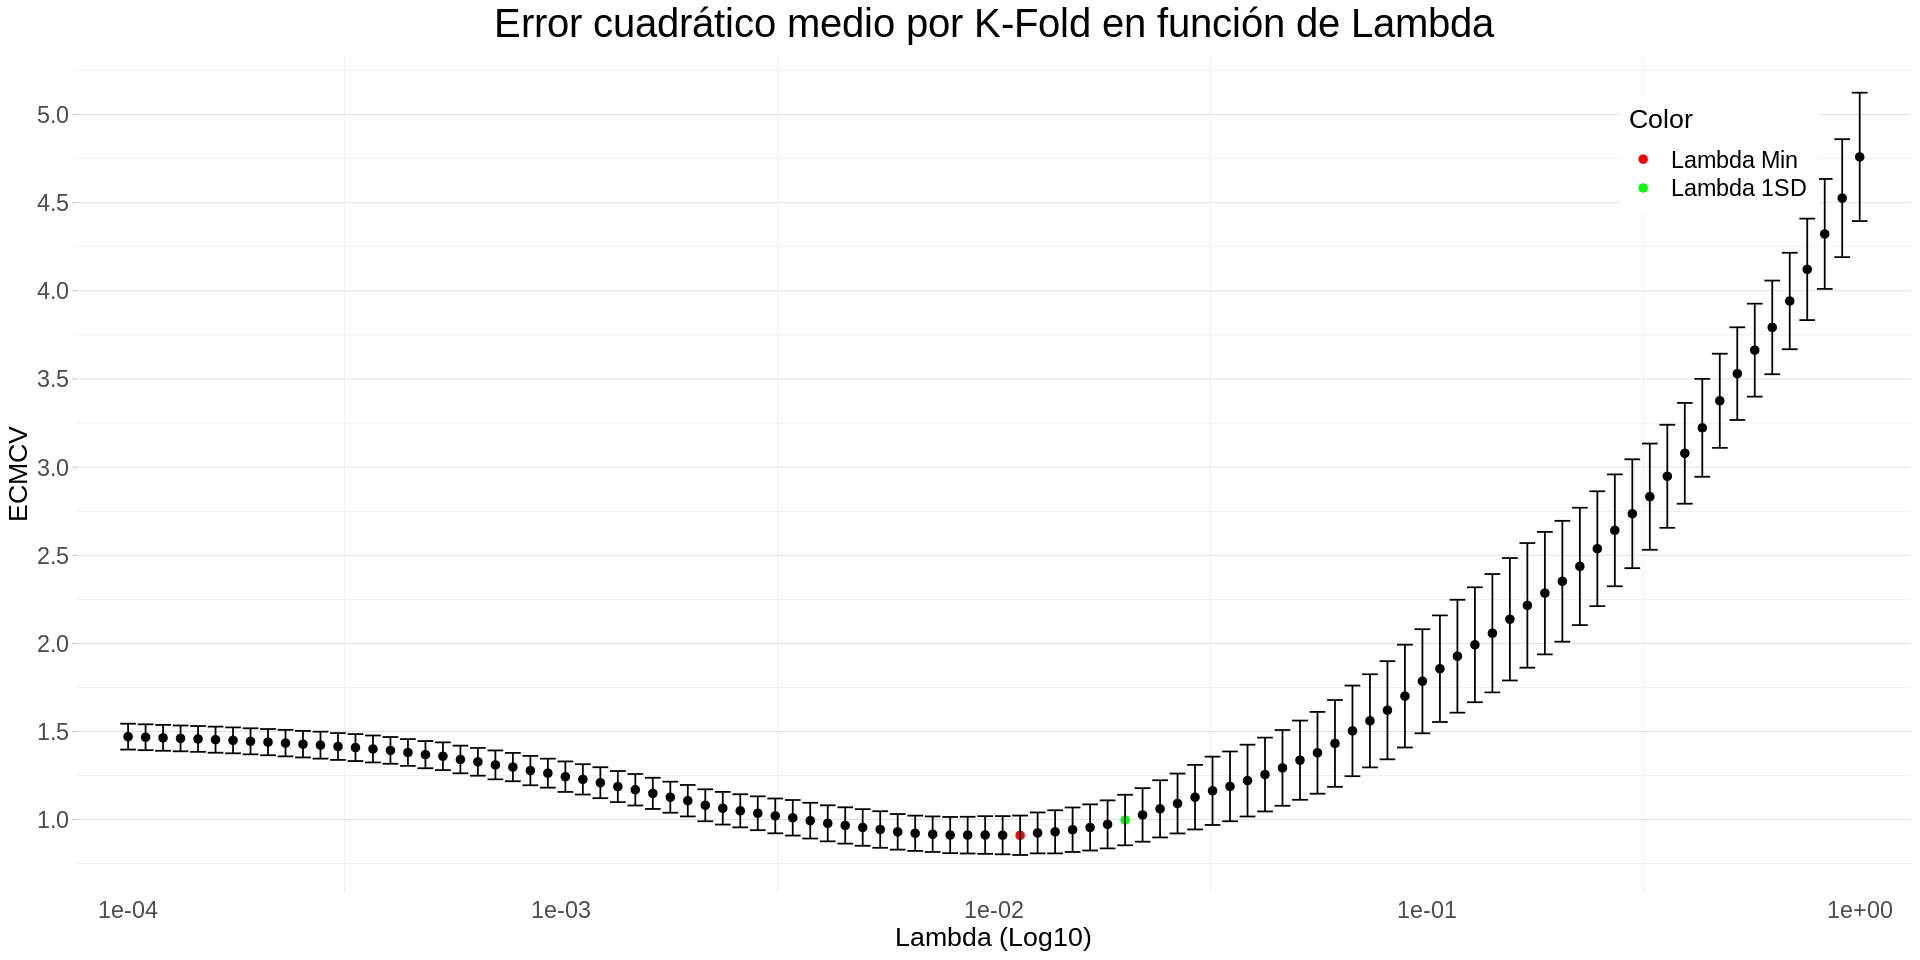

In [7]:
options(repr.plot.width=16, repr.plot.height=8)

ggplot(a, aes(x = Lambda, y = ECMCV)) + 
  ggtitle("Error cuadrático medio por K-Fold en función de Lambda") +
  geom_point(aes(x = Lambda, y = ECMCV,color = Color), size = 2) + 
  geom_errorbar(aes(ymin = ECMCV - SD, ymax = ECMCV + SD)) +
  theme_light() +
  scale_colour_manual(values = c("LambdaMin" = "red", "LambdaOp" = "Green", "Nada" = "Black"),
                      labels = c("Lambda Min", "Lambda 1SD"), breaks = c("LambdaMin", "LambdaOp")) + 
  theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank(),
        legend.position = c(.95, .95),
        legend.justification = c("right", "top"),
        legend.box.just = "right",
        legend.margin = margin(6, 6, 6, 6),
        legend.title = element_text(size=16),
        legend.text = element_text(size=14)) +
  scale_x_continuous(trans = 'log10',  expand = c(0,0.1), breaks = logspace(-6, 0, 7)) +
  scale_y_continuous(breaks = seq(0, 6, by=0.5)) +
  xlab("Lambda (Log10)") + ylab("ECMCV")

### Calculo del error por LOOCV

In [8]:
setSeed()
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, 8)
X <- TRAIN_X
errores = c()
escalador = MMScaler()
for(i in indices){
    X_scaled <- as.matrix(escalador$fit_transform(X[-i,]))
    cv_result <- cv.glmnet(X_scaled, TRAIN_Y[-i], alpha = 1, lambda = logspace(-4, 0, 100), nfolds = 5)
    lambda_sd_k = cv_result$lambda.1se
    modelo_lasso <- glmnet(X_scaled, TRAIN_Y[-i], alpha=1, lambda=lambda_sd_k)
    variables_to_filter = modelo_lasso$beta[,1] != 0

    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, variables_to_filter]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, variables_to_filter]))
    Y_test = TRAIN_Y[i]

    model <- glmnet(X_train_scaled, Y_train, lambda=lambda_min, alpha=1)
    Y_pred = predict(model, X_test_scaled)
    errores = c(errores, mean((Y_test - Y_pred)^2))
}
err = mean(errores)
print(paste("El error cuadratico medio con 8 Folds de train es: ", err))
print(paste("El sd del error cuadratico medio con 8 Folds de train es: ", sd(errores)))

[1] "El error cuadratico medio con 8 Folds de train es:  0.987634416762641"
[1] "El sd del error cuadratico medio con 8 Folds de train es:  0.231489090378305"


In [9]:
X_scaled <- as.matrix(escalador$fit_transform(TRAIN_X))
X_holdout_scaled_modelo_1 = as.matrix(escalador$transform(HOLDOUT_X))
modelo1 <- glmnet(X_scaled, TRAIN_Y, alpha=1, lambda=lambda_optimo)

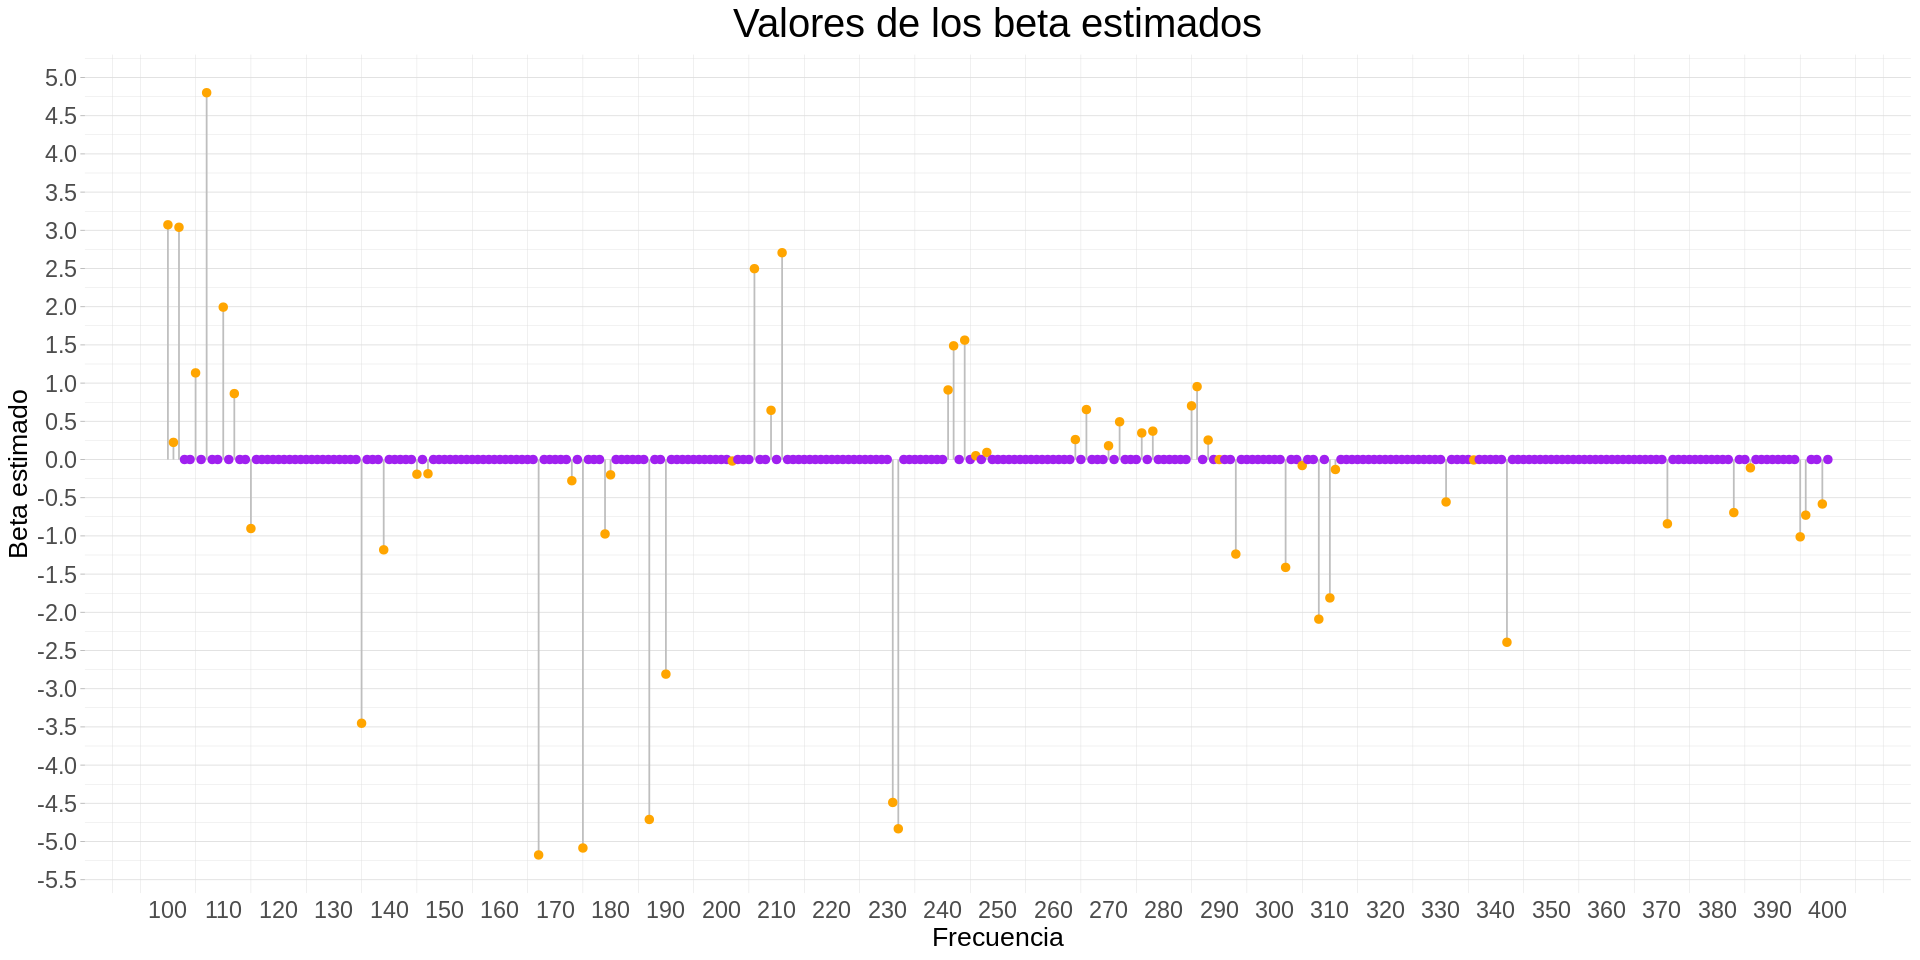

In [10]:
x_plot = as.integer(sub('.', '', colnames(TRAIN_X))) + 99

data_plot <- data.frame(
  x=x_plot,
  y=modelo1$beta[,1]
)


# Plot

options(repr.plot.width=16, repr.plot.height=8)

colores = sapply(modelo1$beta[,1], function(x) (ifelse(x!=0, "orange",  "purple")))
ggplot(data_plot, aes(x=x, y=y)) +
  ggtitle("Valores de los beta estimados") +
  geom_segment( aes(x=x, xend=x, y=0, yend=y), color="grey") +
  geom_point(color=colores, size=2) +
  theme_light() +
  theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank()) +
  scale_x_continuous(breaks = seq(100, 400, by=10)) +
  scale_y_continuous(breaks = seq(-6, 6, by=0.5)) +
  xlab("Frecuencia") + ylab("Beta estimado")

In [11]:
variables_to_filter = modelo1$beta[,1] != 0
print(paste("El mejor modelo de Lasso encontrado elimina en general ", sum(modelo1$beta[,1] == 0), " variables"))
print(paste("El mejor modelo de Lasso encontrado se quedo con ", sum(modelo1$beta[,1] != 0), " variables"))

[1] "El mejor modelo de Lasso encontrado elimina en general  246  variables"
[1] "El mejor modelo de Lasso encontrado se quedo con  55  variables"


In [12]:
p = sum(modelo1$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.914363660255997"


In [13]:
SELECTED_TRAIN_X <- TRAIN_X[, variables_to_filter]
SELECTED_TRAIN_DF <- SELECTED_TRAIN_X
SELECTED_TRAIN_DF$Y <- TRAIN_Y

SELECTED_HOLDOUT_X <- HOLDOUT_X[, variables_to_filter]
SELECTED_HOLDOUT_DF <- SELECTED_HOLDOUT_X
SELECTED_HOLDOUT_DF$Y <- HOLDOUT_Y

# Modelo 2: Regresion Lineal

In [14]:
# No escalamos los datos porque no hay regularizacion.
modelo2 <- lm(Y~., data = SELECTED_TRAIN_DF)

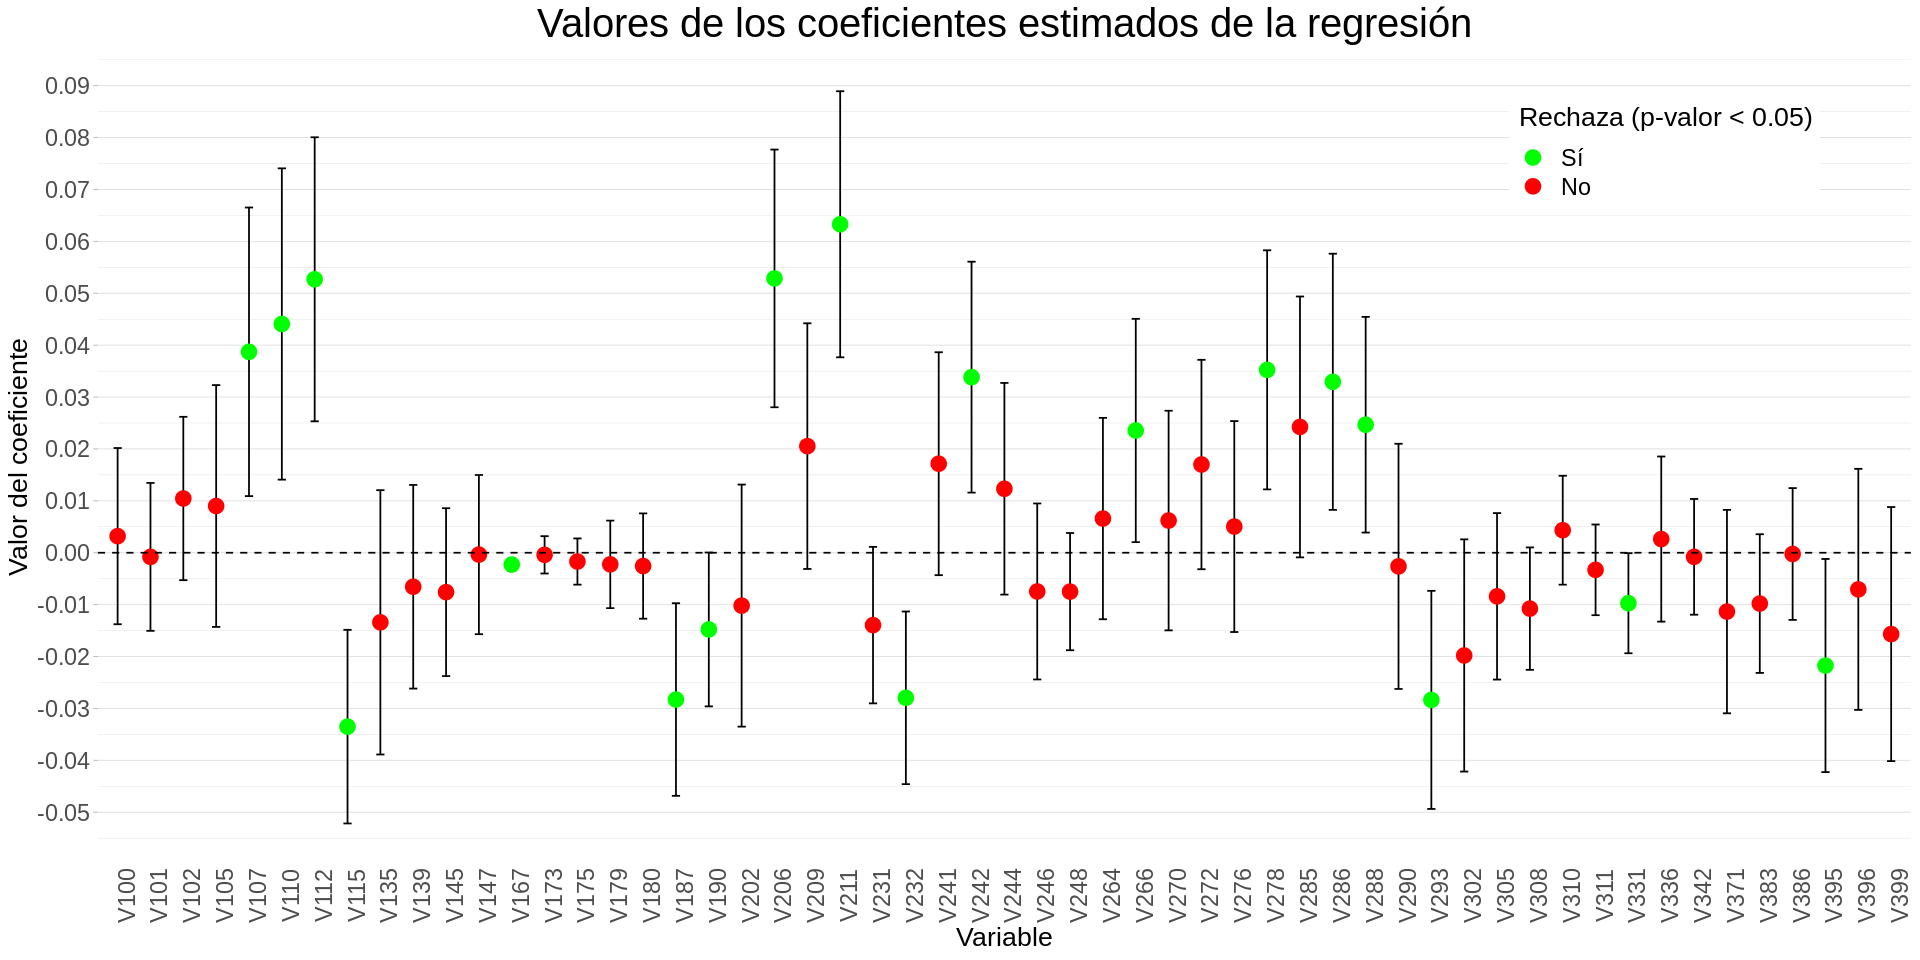

In [15]:
a <- summary(modelo2)
x_plot = paste("V", as.integer(sub('.', '', colnames(SELECTED_TRAIN_X))) + 99, sep="")
data_plot <- data.frame(
    x=x_plot,
    y=a$coefficients[-1, 1],
    sd=a$coefficients[-1, 2],
    col=(a$coefficients[-1, 4] < 0.05)
)
colnames(data_plot) <- c("V", "Estimate", "SD", "Rechaza")

options(repr.plot.width=16, repr.plot.height=8)

ggplot(data_plot, aes(x = V, y = Estimate)) + 
  ggtitle("Valores de los coeficientes estimados de la regresión") +
  geom_errorbar(aes(ymin = Estimate - 2*SD, ymax = Estimate + 2*SD),  width=0.25) +
  geom_point(aes(color = Rechaza), size = 4) + 
  theme_light() +
  scale_colour_manual(values = c("TRUE" = "green", "FALSE" = "red"),
                      labels = c("Sí", "No"), breaks = c("TRUE", "FALSE")) + 
  theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text.y=element_text(size=14),
        axis.text.x=element_text(size=14, angle = 90),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank(),
        legend.position = c(.95, .95),
        legend.justification = c("right", "top"),
        legend.box.just = "right",
        legend.margin = margin(6, 6, 6, 6),
        legend.title = element_text(size=16),
        legend.text = element_text(size=14)) +
  geom_hline(yintercept=0, linetype="dashed") + 
  guides(color=guide_legend("Rechaza (p-valor < 0.05)")) +
  scale_y_continuous(breaks = seq(-1, 1, by=0.01)) +
  xlab("Variable") + ylab("Valor del coeficiente")

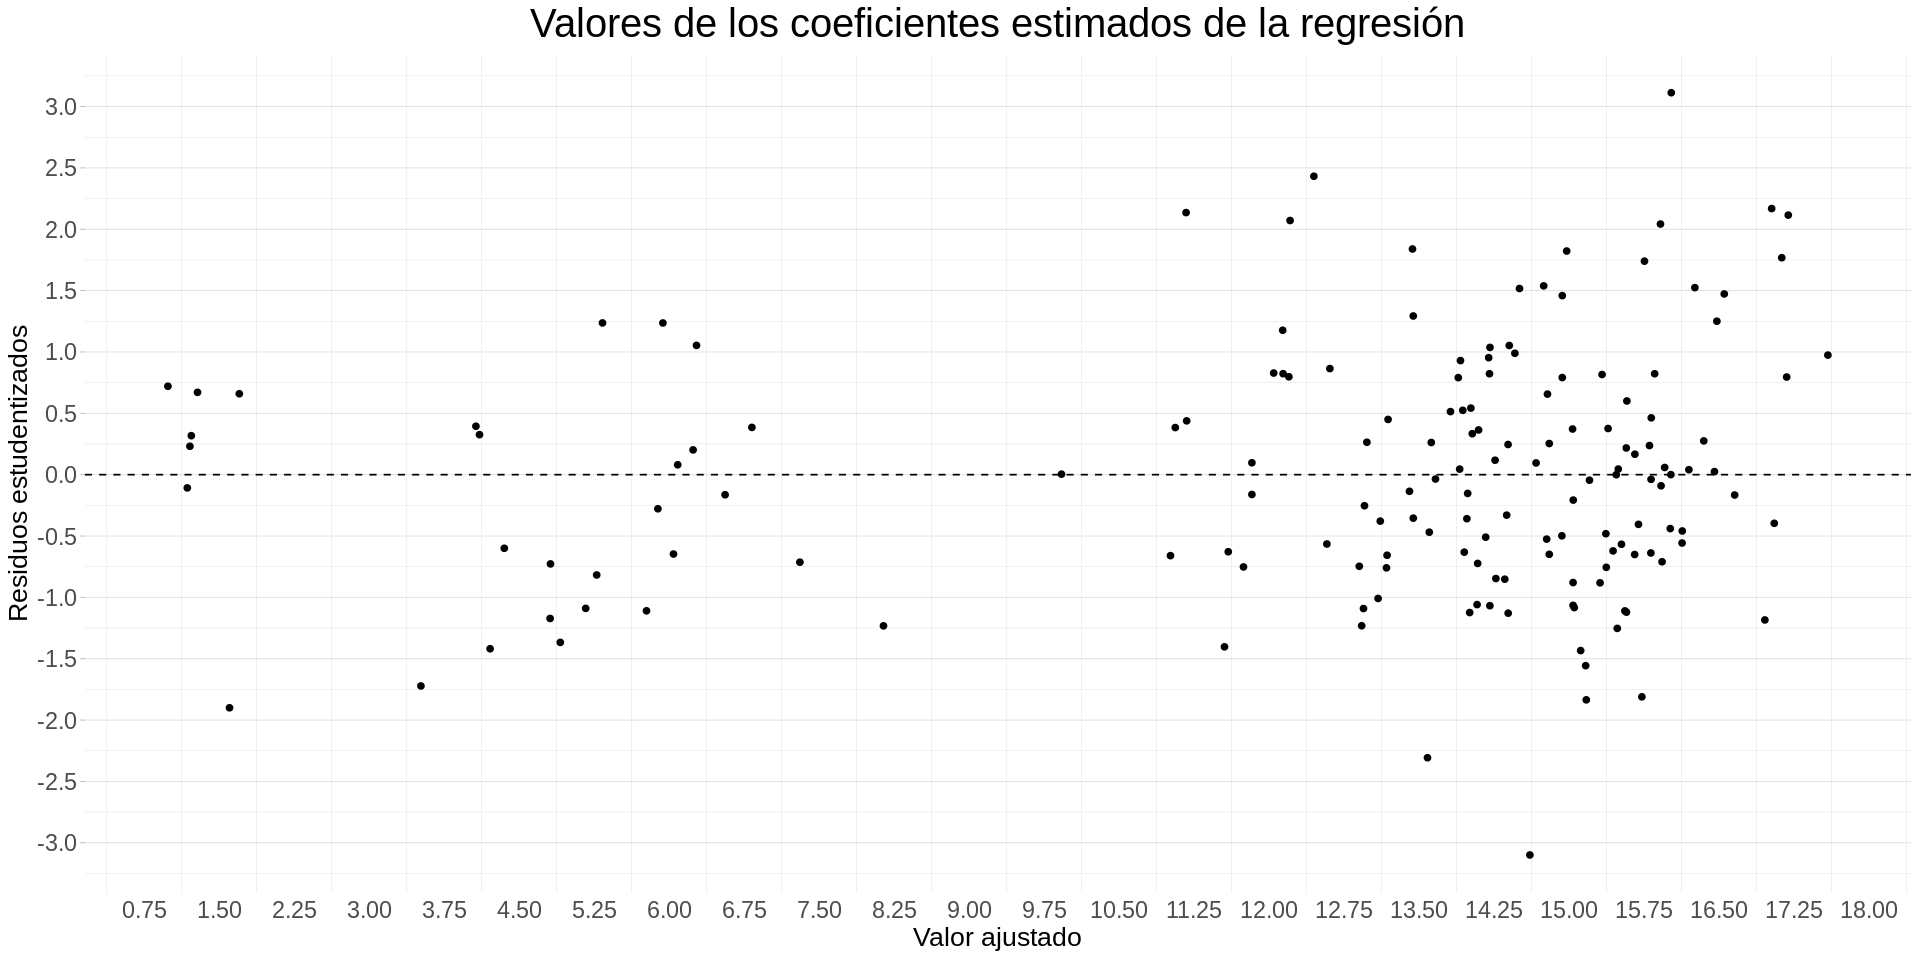

In [16]:
b <- data.frame(
    "y" = SELECTED_TRAIN_DF$Y,
    "tmenosi" = studres(modelo2)
)
options(repr.plot.width=16, repr.plot.height=8)
ggplot(b, aes(x=y, y=tmenosi)) +
    ggtitle("Valores de los coeficientes estimados de la regresión") +
    geom_point()+
    theme_light() +
    theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank()) +
    geom_hline(yintercept=0, linetype="dashed") + 
    scale_x_continuous(breaks = seq(0, 20, by=0.75)) +
    scale_y_continuous(breaks = seq(-4, 4, by=0.5)) + 
    xlab("Valor ajustado") + ylab("Residuos estudentizados")

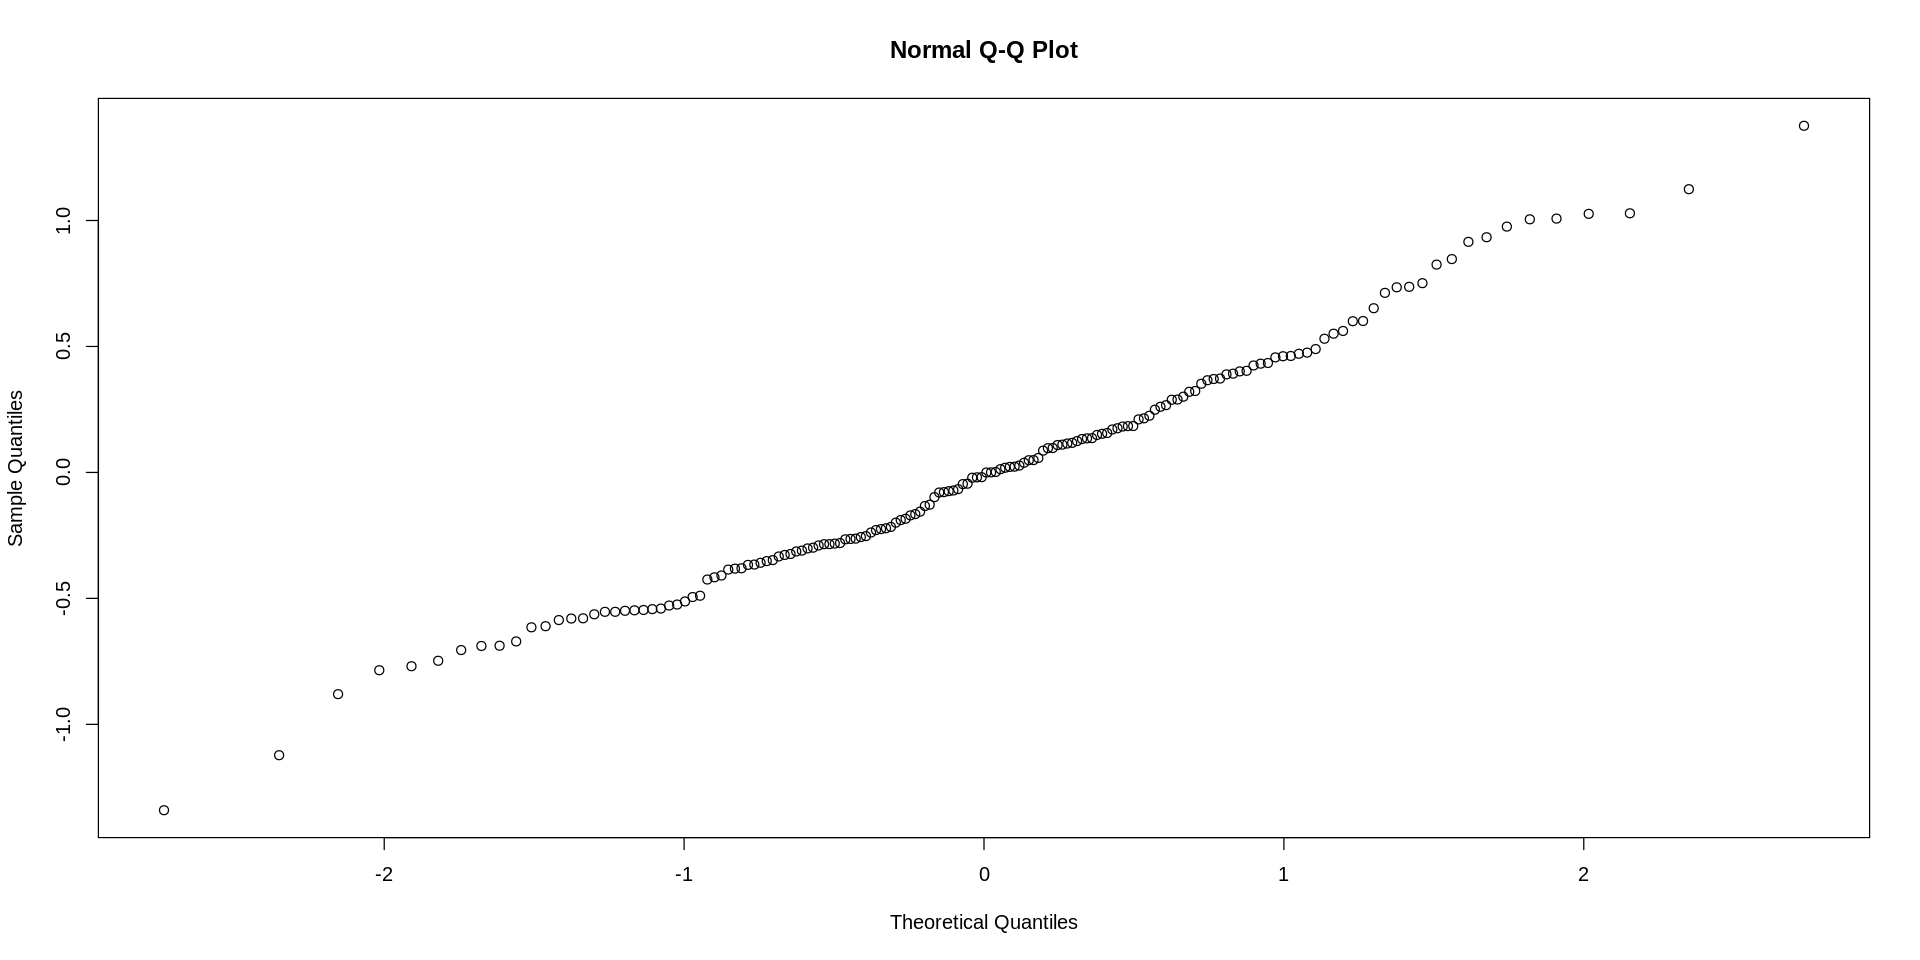

In [17]:
data_plot <- as.data.frame(qqnorm(modelo2$residuals))

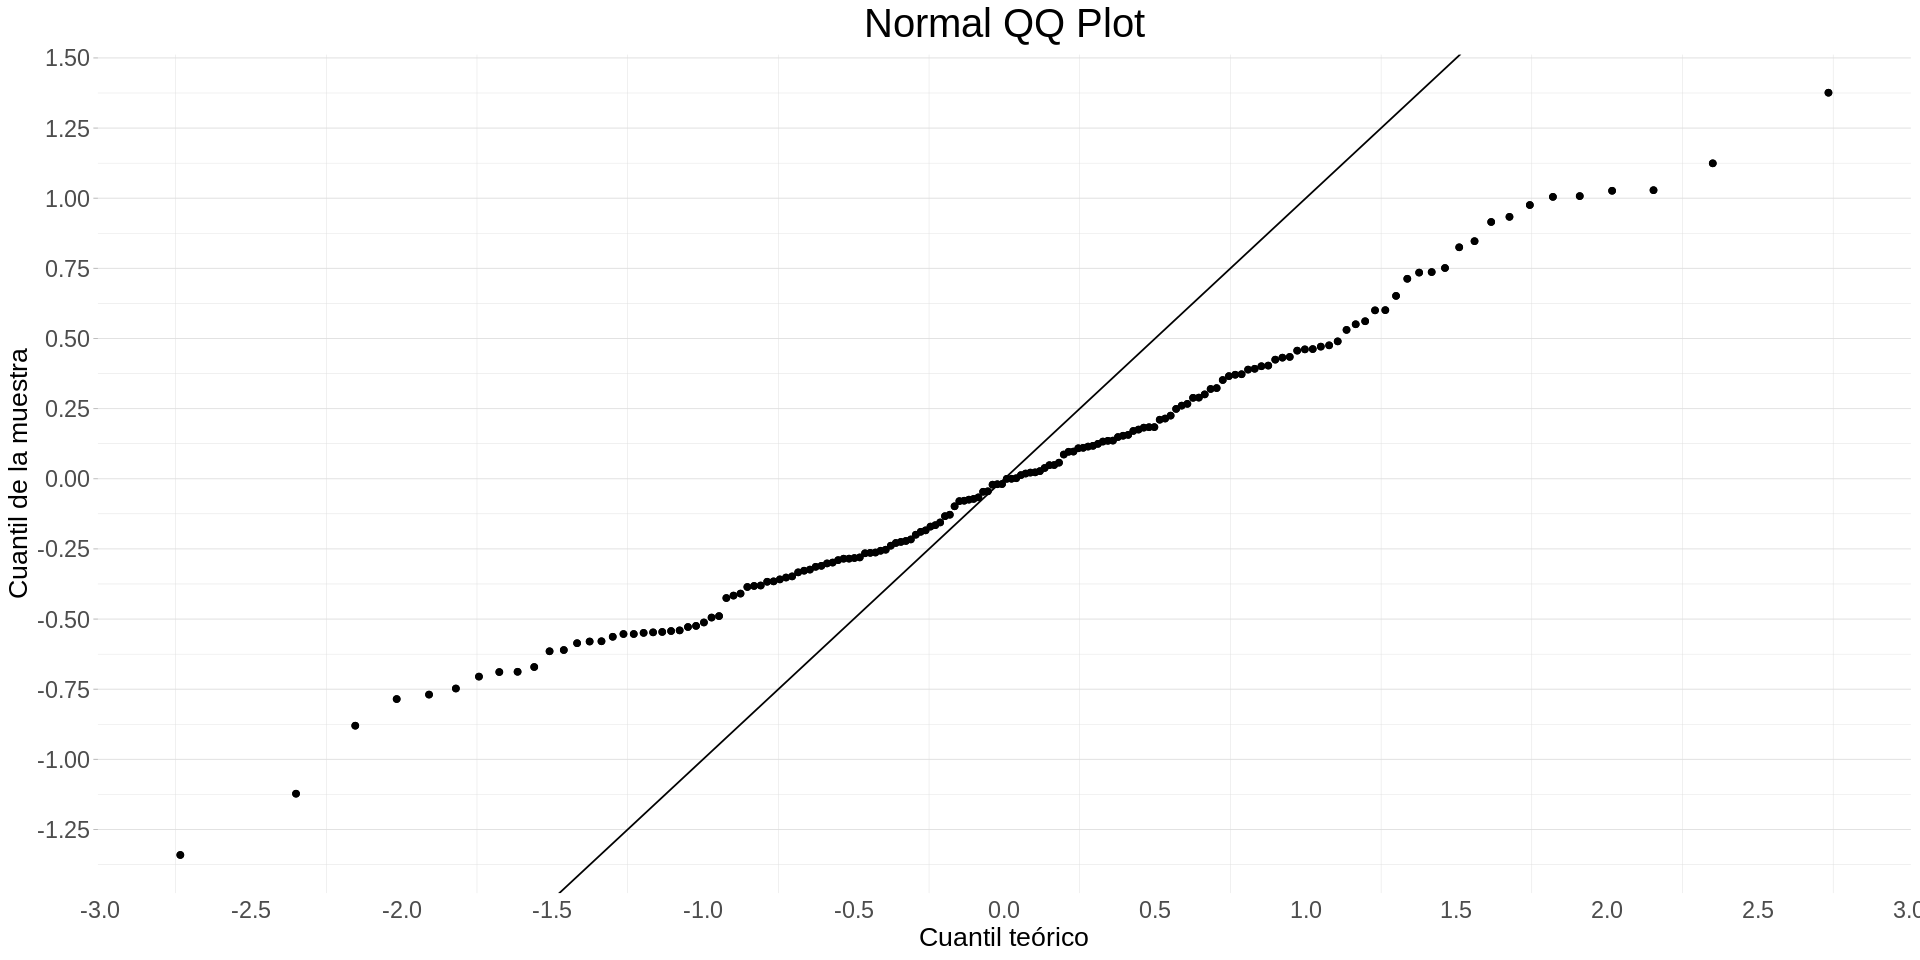

In [18]:
options(repr.plot.width=16, repr.plot.height=8)

ggplot(data_plot, aes(x=x, y=y)) +
    geom_point() +
    geom_abline(slope = 1, intercept = 0) +
    ggtitle("Normal QQ Plot") +
    geom_point()+
    theme_light() +
    theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank()) +
    xlab("Cuantil teórico") + ylab("Cuantil de la muestra")+
    scale_x_continuous(breaks = seq(-5, 5, by=0.5)) +
    scale_y_continuous(breaks = seq(-2, 2, by=0.25))

In [19]:
setSeed()
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, 8)
X <- TRAIN_X
errores = c()
escalador_lasso = MMScaler()
for(i in indices){
    X_scaled <- as.matrix(escalador_lasso$fit_transform(X[-i,]))
    cv_result <- cv.glmnet(X_scaled, TRAIN_Y[-i], alpha = 1, lambda = logspace(-4, 0, 100), nfolds = 5)
    lambda_optimo = cv_result$lambda.1se
    modelo_lasso <- glmnet(X_scaled, TRAIN_Y[-i], alpha=1, lambda=lambda_optimo)
    variables_to_filter = modelo_lasso$beta[,1] != 0
    df_train = X[-i,variables_to_filter]
    df_train$Y = TRAIN_Y[-i]
    
    X_test = X[i,variables_to_filter]
    Y_test = TRAIN_Y[i]

    model <- lm(Y~.,  data = df_train)
    Y_pred = predict(model, X_test)
    errores = c(errores, mean((Y_test - Y_pred)^2))
}
err = mean(errores)
print(paste("El error cuadratico medio con LOOCV de train es: ", err))
print(paste("El sd del error cuadratico medio con LOOCV de train es: ", sd(errores)))

[1] "El error cuadratico medio con LOOCV de train es:  0.974426109372614"
[1] "El sd del error cuadratico medio con LOOCV de train es:  0.218052762825539"


In [20]:
p = sum(modelo1$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.915508933324551"


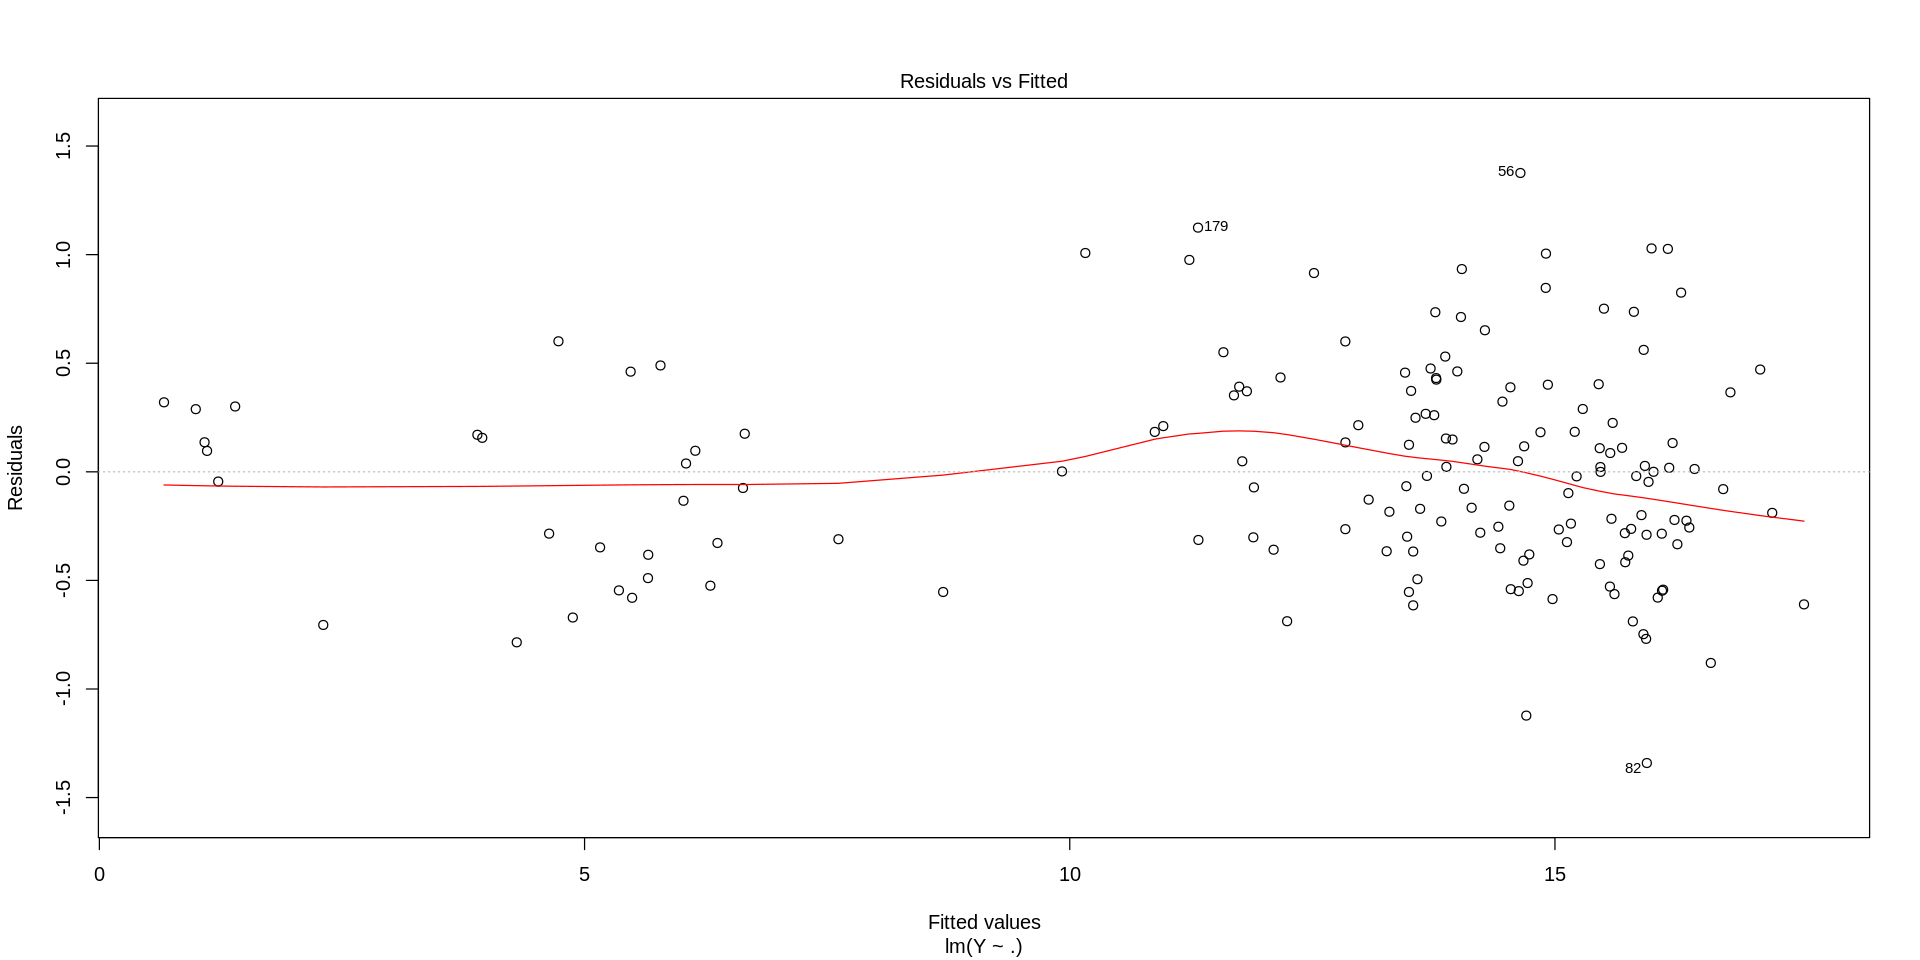

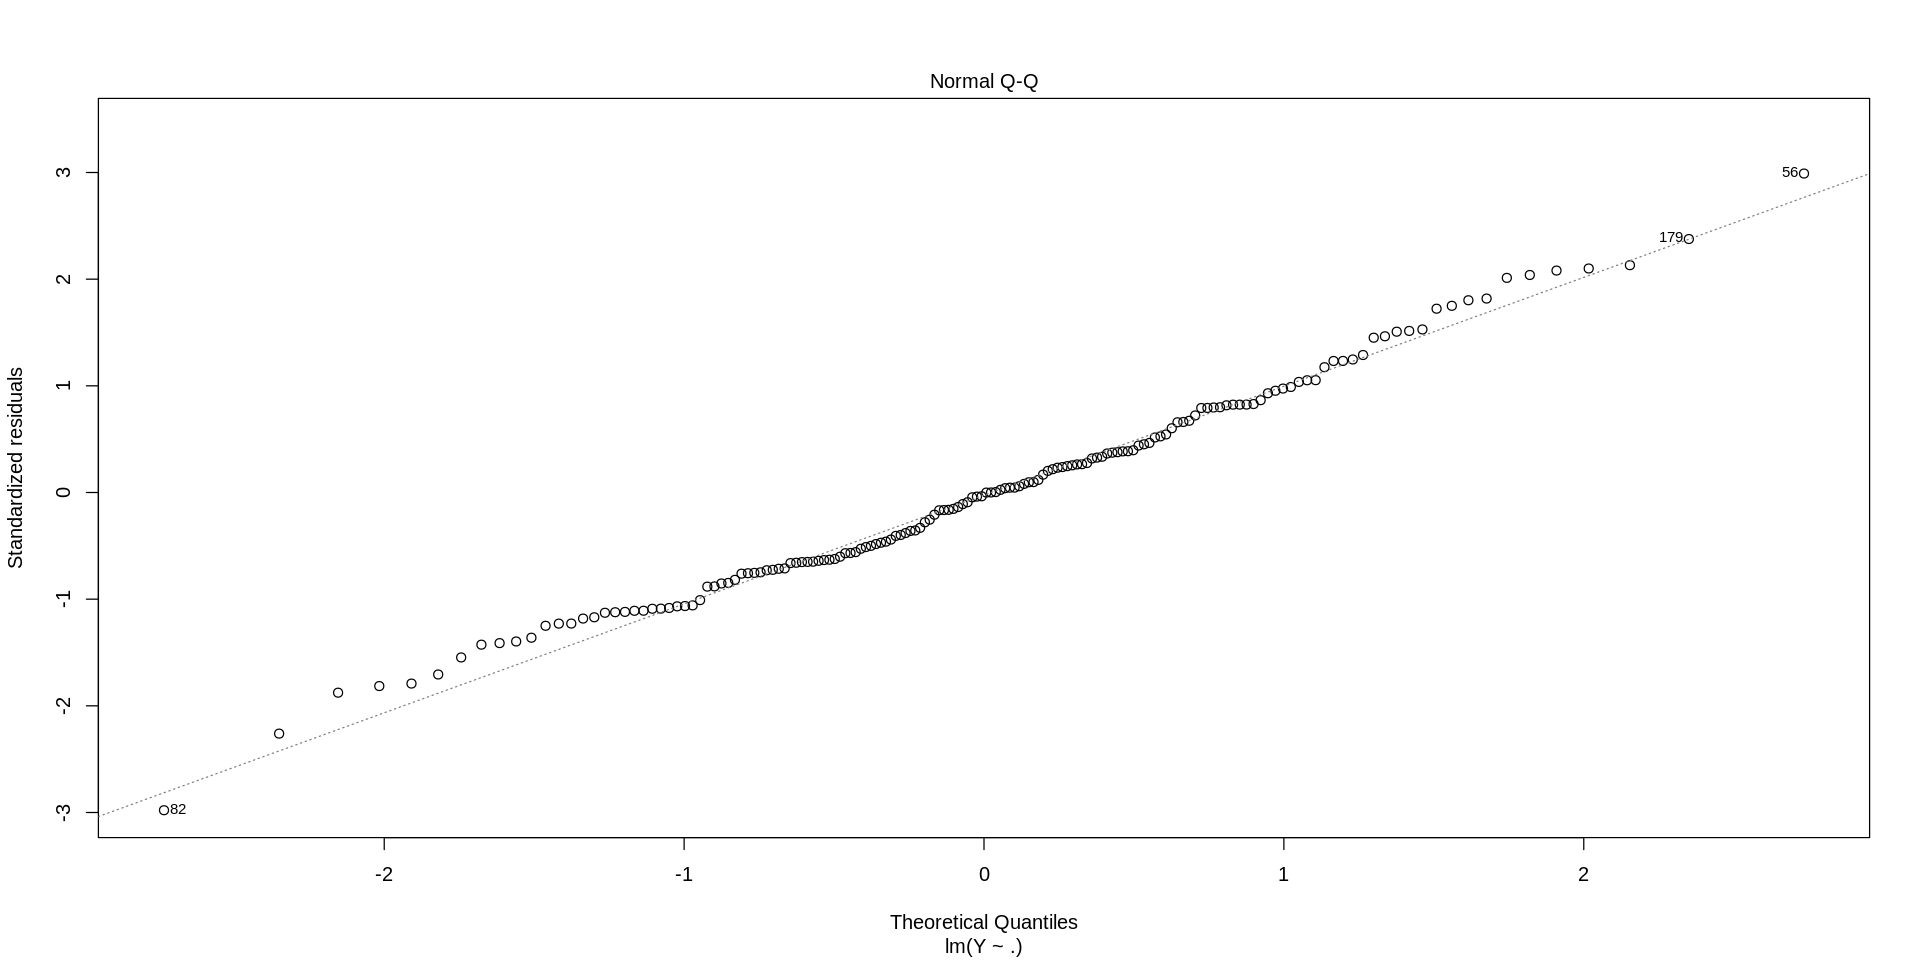

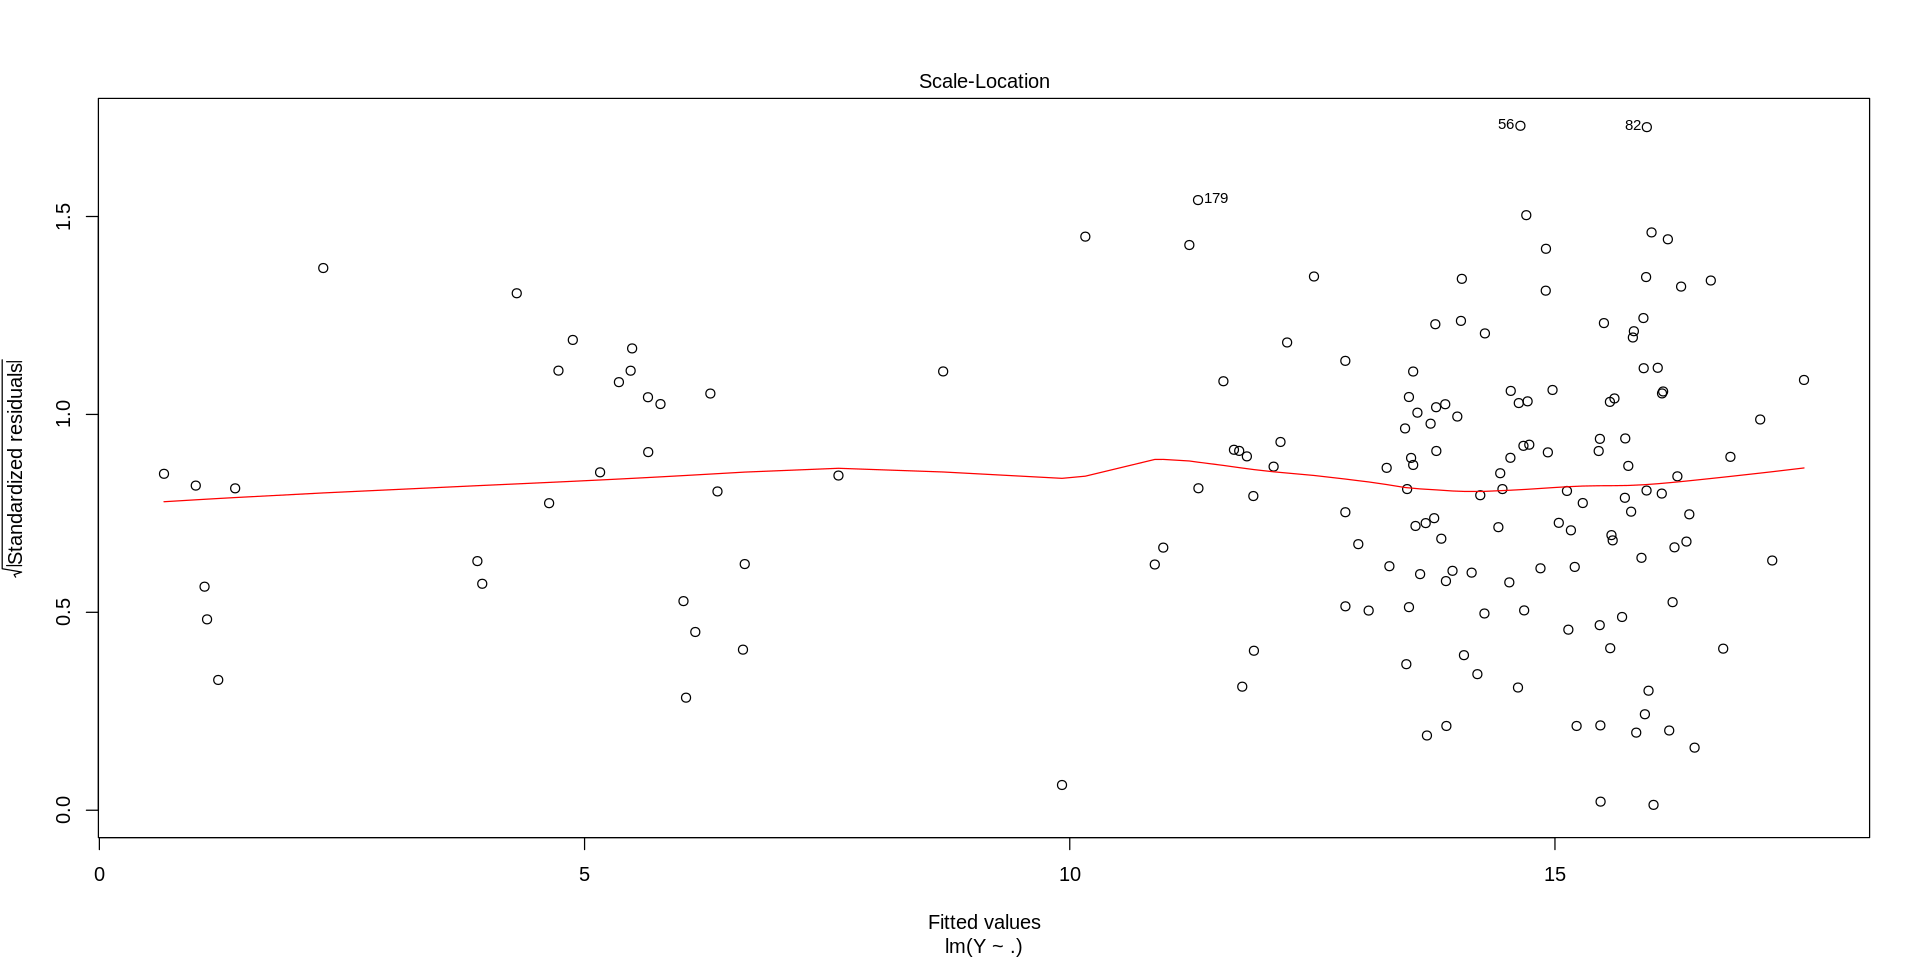

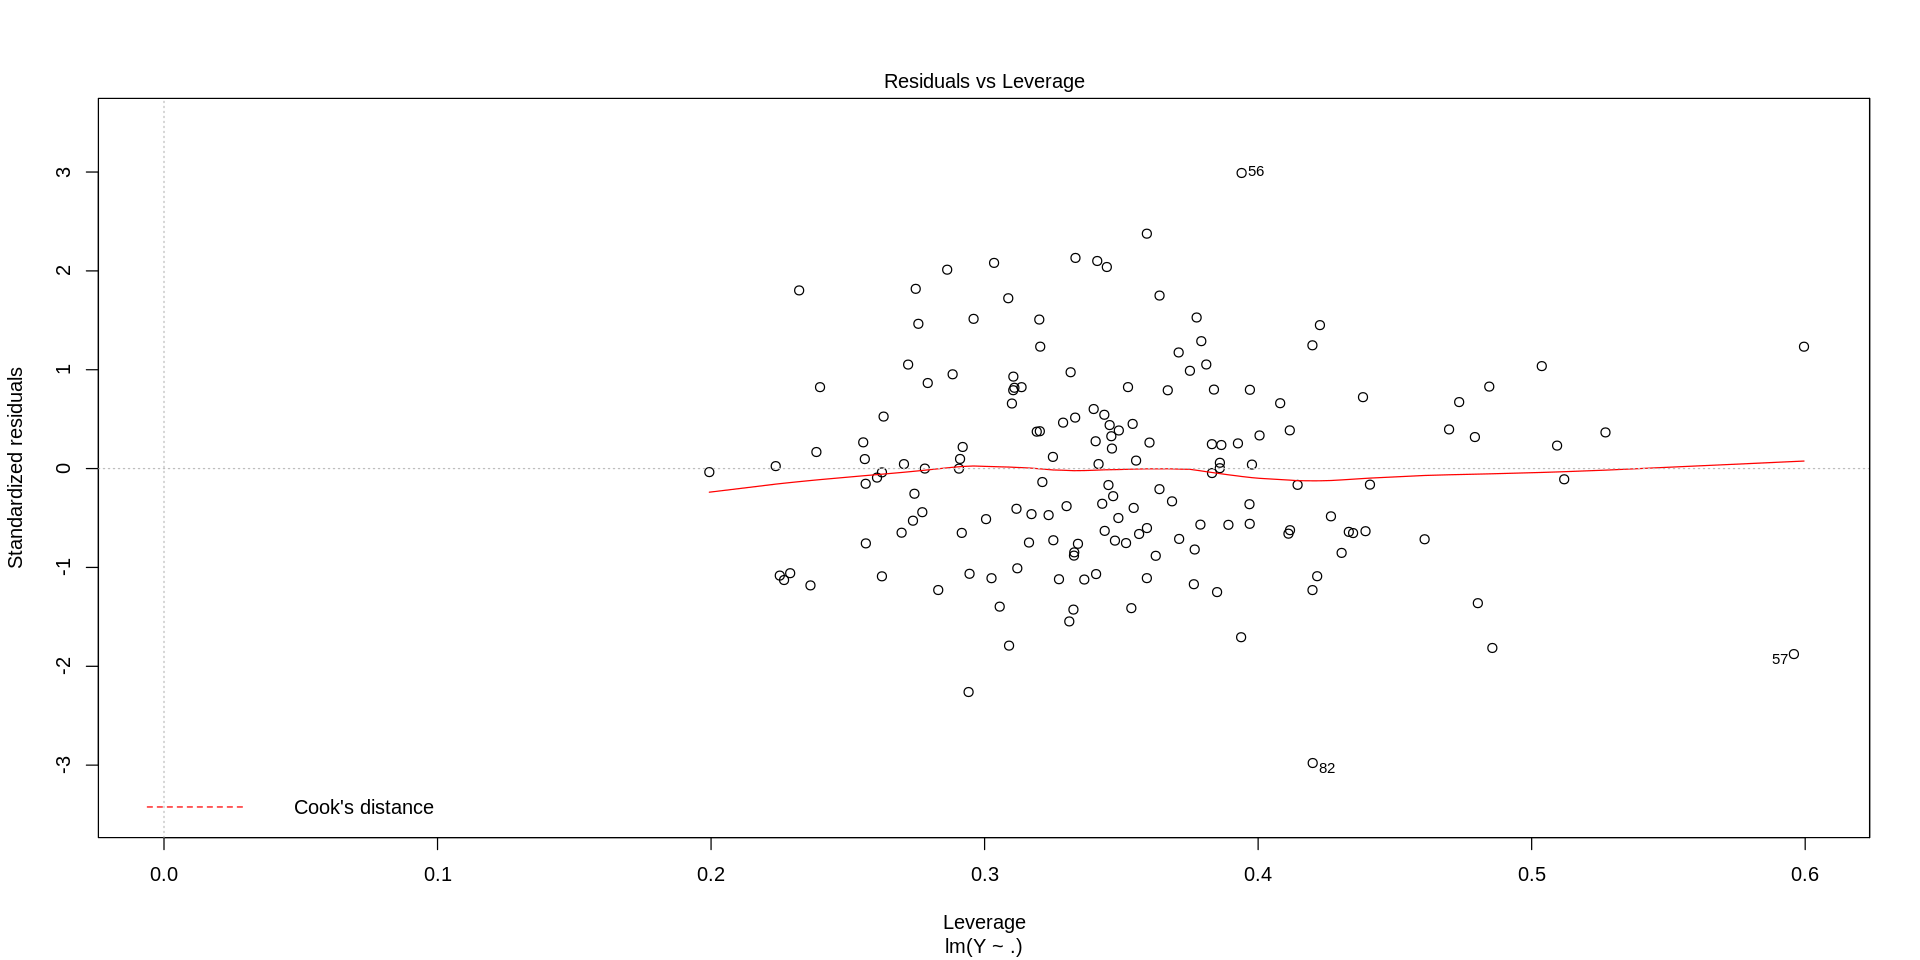

In [21]:
plot(modelo2)

# Modelo 3: Ridge

### Busqueda de los parametros de la prediccion

In [22]:
setSeed()
n = nrow(TRAIN_X)
k = 8
resultados <- data.frame(
  Alpha   =double(),
  Lambda  =double(),
  Escalador = integer(),
  Error   =double()
)

indices = obtener_indices_kfold(n, k)
X <- TRAIN_X

alpha <- 0 # para que sea ridge
lambdas <- logspace(-10, 3, 50)
escaladores <- c(StScaler(), MMScaler())
escalador_lasso = MMScaler()

lambdas_optimos <- c()

for (i in indices) {
    X_scaled <- as.matrix(escalador_lasso$fit_transform(TRAIN_X[-i, ]))
    cv_result <- cv.glmnet(X_scaled, TRAIN_Y[-i], alpha = 1, lambda = logspace(-4, 0, 100), nfolds = 5)
    lambda_optimo = cv_result$lambda.1se
    lambdas_optimos <- c(lambdas_optimos, lambda_optimo)
}

for (lambda in lambdas) {
    for(s in 1:length(escaladores)){
        escalador = escaladores[[s]] 
        err = 0
        index_i = 1
        for (i in indices) {
            X_scaled <- as.matrix(escalador_lasso$fit_transform(TRAIN_X[-i, ]))
            modelo_lasso <- glmnet(X_scaled, TRAIN_Y[-i], alpha=1, lambda=lambdas_optimos[index_i])
            variables_to_filter = modelo_lasso$beta[,1] != 0

            X_train_scaled = as.matrix(escalador$fit_transform(X[-i, variables_to_filter]))
            Y_train = TRAIN_Y[-i]

            X_test_scaled = as.matrix(escalador$transform(X[i, variables_to_filter]))
            Y_test = TRAIN_Y[i]

            model <- glmnet(X_train_scaled, Y_train, lambda=lambda, alpha=alpha)
            Y_pred = predict(model, X_test_scaled)
            err = err + sum((Y_test - Y_pred)^2)
            index_i = index_i + 1
        }
        resultados = rbind(resultados, list(alpha, lambda, s, err/n))
    }
    message(progreso(lambda, lambdas))

}

colnames(resultados)  <- c("alpha", "lambda", "Escalador", "Error")

El progreso es del 2 %
El progreso es del 4 %
El progreso es del 6 %
El progreso es del 8 %
El progreso es del 10 %
El progreso es del 12 %
El progreso es del 14 %
El progreso es del 16 %
El progreso es del 18 %
El progreso es del 20 %
El progreso es del 22 %
El progreso es del 24 %
El progreso es del 26 %
El progreso es del 28 %
El progreso es del 30 %
El progreso es del 32 %
El progreso es del 34 %
El progreso es del 36 %
El progreso es del 38 %
El progreso es del 40 %
El progreso es del 42 %
El progreso es del 44 %
El progreso es del 46 %
El progreso es del 48 %
El progreso es del 50 %
El progreso es del 52 %
El progreso es del 54 %
El progreso es del 56 %
El progreso es del 58 %
El progreso es del 60 %
El progreso es del 62 %
El progreso es del 64 %
El progreso es del 66 %
El progreso es del 68 %
El progreso es del 70 %
El progreso es del 72 %
El progreso es del 74 %
El progreso es del 76 %
El progreso es del 78 %
El progreso es del 80 %
El progreso es del 82 %
El progreso es del 8

Los mejores parámetros obtenidos fueron entonces:

In [23]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,alpha,lambda,Escalador,Error
63,0,0.01676833,1,0.975413


### Calculo del error por LOOCV

In [24]:
n = nrow(TRAIN_X)
#indices = obtener_indices_kfold(n, 5)
X <- TRAIN_X
escalador = escaladores[[mejores_parametros$Escalador]]

errores = c()
escalador_lasso = MMScaler()
index_i = 1
for(i in indices){
    X_scaled <- as.matrix(escalador_lasso$fit_transform(X[-i,]))
    modelo_lasso <- glmnet(X_scaled, TRAIN_Y[-i], alpha=1, lambda=lambdas_optimos[index_i])
    variables_to_filter = modelo_lasso$beta[,1] != 0
    
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, variables_to_filter]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, variables_to_filter]))
    Y_test = TRAIN_Y[i]
    
    model <- glmnet(X_train_scaled, Y_train, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)
    Y_pred = predict(model, X_test_scaled)
    errores = c(errores, mean((Y_test - Y_pred)^2))
    index_i = index_i + 1
}
err = mean(errores)
print(paste("El error cuadratico medio con LOOCV de train es: ", err))
print(paste("El sd del error cuadratico medio con LOOCV de train es: ", sd(errores)))

[1] "El error cuadratico medio con LOOCV de train es:  0.975413027979062"
[1] "El sd del error cuadratico medio con LOOCV de train es:  0.237457017142861"


In [25]:
X_train_scaled <- as.matrix(escalador$fit_transform(SELECTED_TRAIN_X))
X_holdout_scaled_modelo3 <- as.matrix(escalador$transform(SELECTED_HOLDOUT_X))
modelo3 <- glmnet(X_train_scaled, TRAIN_Y, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)

p = sum(modelo3$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.915423359051676"


# Modelo 4: árbol de regresión

### Busqueda de los parametros de la prediccion

In [26]:
library(rpart)
library(rpart.plot)

In [27]:
setSeed()

n = nrow(TRAIN_X)
k = 8

resultados <- data.frame(
  Minsplit =double(),
  Maxdepth =double(),
  CP       =double(),
  Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- TRAIN_X
escalador_lasso = MMScaler()

lambdas_optimos <- c()

for (i in indices) {
    X_scaled <- as.matrix(escalador_lasso$fit_transform(TRAIN_X[-i, ]))
    cv_result <- cv.glmnet(X_scaled, TRAIN_Y[-i], alpha = 1, lambda = logspace(-4, 0, 100), nfolds = 5)
    lambda_optimo = cv_result$lambda.1se
    lambdas_optimos <- c(lambdas_optimos, lambda_optimo)
}

minsplits <- c(2, 5, 10, 20, 30, 50)

for (minsplit in minsplits) {
    for (maxdepth in c(4, 5, 6, 7, 8)) {
        for (cp in c(0.0005, 0.001, 0.005, 0.01, 0.015, 0.025)) {
            parametros = rpart.control(minsplit=minsplit, maxdepth=maxdepth, cp=cp)
            err = 0
            index_i = 1
            for(i in indices) {
                X_scaled <- as.matrix(escalador_lasso$fit_transform(TRAIN_X[-i, ]))
                modelo_lasso <- glmnet(X_scaled, TRAIN_Y[-i], alpha=1, lambda=lambdas_optimos[index_i])
                variables_to_filter = modelo_lasso$beta[,1] != 0
                
                DF_train = X[-i,variables_to_filter]
                DF_train$Y = TRAIN_Y[-i]

                DF_test = X[i,variables_to_filter]
                DF_test$Y = TRAIN_Y[i]
                
                model <- rpart(Y ~ ., data = DF_train, control=parametros, xval=1)
                Y_pred = predict(model, DF_test)
                err = err + sum((DF_test$Y - Y_pred)^2)
                index_i = index_i + 1
            }
            resultados = rbind(resultados, list(minsplit, maxdepth, cp, err/n))
        }
    }
    message(progreso(minsplit, minsplits))
}

colnames(resultados)  <- c("Minsplit", "Maxdepth", "CP", "Error")

El progreso es del 16.7 %
El progreso es del 33.3 %
El progreso es del 50 %
El progreso es del 66.7 %
El progreso es del 83.3 %
El progreso es del 100 %


In [28]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,Minsplit,Maxdepth,CP,Error
55,5,8,5e-04,1.46186


### Calculo del error

In [29]:
parametros <- rpart.control(minsplit=mejores_parametros$Minsplit, maxdepth=mejores_parametros$Maxdepth, cp=mejores_parametros$CP)

modelo4 <- rpart(Y ~ ., data = SELECTED_TRAIN_DF, control=parametros)

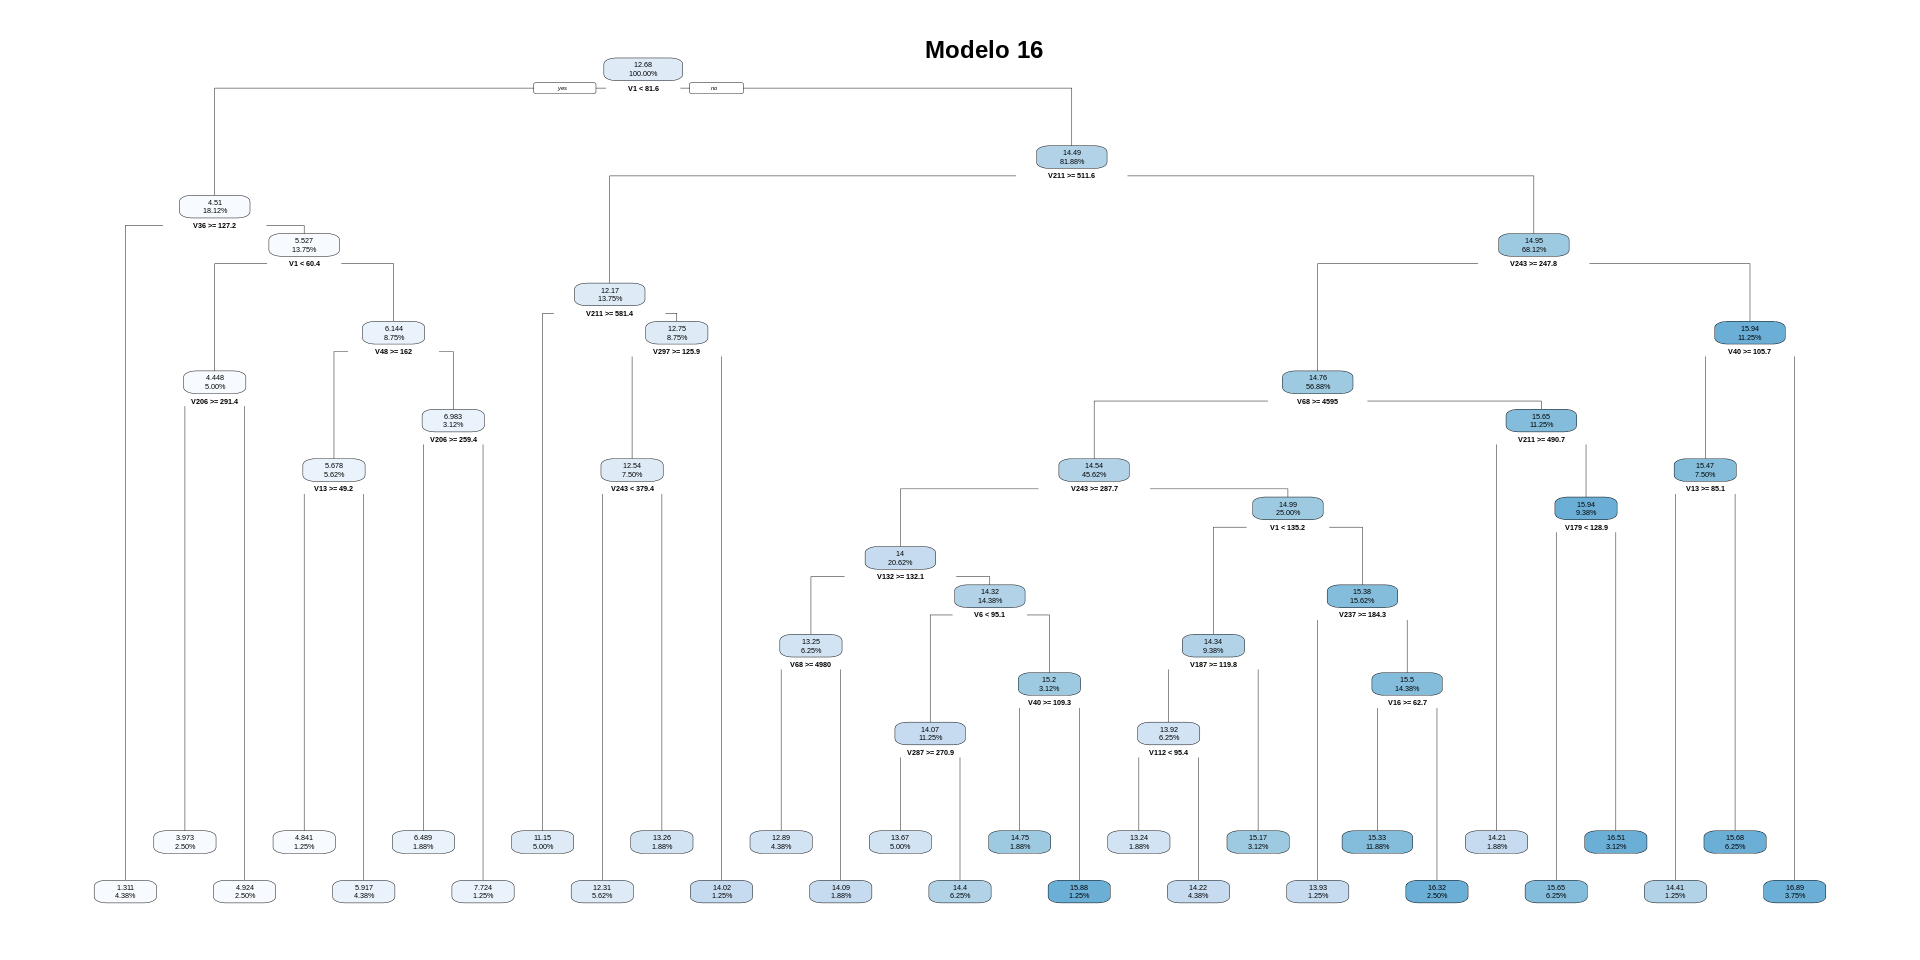

In [30]:
rpart.plot(modelo4, digits=4)
title("Modelo 16")

In [31]:
n = nrow(TRAIN_X)
X <- TRAIN_X
errores <- c()
index_i = 1
for(i in indices){
    X_scaled <- as.matrix(escalador_lasso$fit_transform(TRAIN_X[-i, ]))
    modelo_lasso <- glmnet(X_scaled, TRAIN_Y[-i], alpha=1, lambda=lambdas_optimos[index_i])
    variables_to_filter = modelo_lasso$beta[,1] != 0
    
    train_df <- X[-i,variables_to_filter]
    train_df$Y <- TRAIN_Y[-i]
    X_test <- X[i,variables_to_filter]
    Y_test = TRAIN_Y[i]

    model <- rpart(Y ~ ., data = train_df, control=parametros)
    Y_pred = predict(model, X_test)
    errores <- c(errores, mean((Y_test - Y_pred)^2))
    index_i = index_i + 1
}
err = mean(errores)
print(paste("El error cuadratico medio con LOOCV de train es: ", err))
print(paste("El sd del error cuadratico medio con LOOCV de train es: ", sd(errores)))

[1] "El error cuadratico medio con LOOCV de train es:  1.46186039463681"
[1] "El sd del error cuadratico medio con LOOCV de train es:  0.567208806117702"


In [32]:
p <- length(unique(summary(modelo4)$frame$var))-1

Call:
rpart(formula = Y ~ ., data = SELECTED_TRAIN_DF, control = parametros)
  n= 160 

             CP nsplit  rel error     xerror       xstd
1  0.8457815140      0 1.00000000 1.01542310 0.13710723
2  0.0506953513      1 0.15421849 0.17655220 0.02428096
3  0.0337894459      2 0.10352313 0.13482738 0.01680169
4  0.0075050540      3 0.06973369 0.09892421 0.01370560
5  0.0063462695      4 0.06222863 0.10281031 0.01420568
6  0.0052399391      6 0.04953610 0.09843588 0.01417864
7  0.0046736994      7 0.04429616 0.08960779 0.01161775
8  0.0036275726      8 0.03962246 0.09094373 0.01152597
9  0.0028817535      9 0.03599488 0.09165479 0.01149278
10 0.0028432240     10 0.03311313 0.08918433 0.01146225
11 0.0026748385     11 0.03026991 0.08834505 0.01148032
12 0.0019596237     12 0.02759507 0.09482022 0.01257222
13 0.0018452027     13 0.02563545 0.09287838 0.01235017
14 0.0017836937     14 0.02379024 0.09377364 0.01266954
15 0.0016273501     15 0.02200655 0.09315992 0.01239549
16 0.0013444242 

In [33]:
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.906272132589016"


# Modelo 5: KNN para regresión

In [34]:
library(reticulate)

In [35]:
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

In [36]:
knnr <- import("sklearn.neighbors", convert = FALSE)$KNeighborsRegressor

### Busqueda de los parametros de la prediccion

In [37]:
setSeed()

n = nrow(TRAIN_X)
k = 8

resultados <- data.frame(
    K        =integer(),
    Weights  =integer(),
    p        =integer(),
    S        =integer(),
    Error    =double()
)

indices = obtener_indices_kfold(n, k)

lambdas_optimos <- c()
escalador_lasso = MMScaler()

for (i in indices) {
    X_scaled <- as.matrix(escalador_lasso$fit_transform(TRAIN_X[-i, ]))
    cv_result <- cv.glmnet(X_scaled, TRAIN_Y[-i], alpha = 1, lambda = logspace(-4, 0, 100), nfolds = 5)
    lambda_optimo = cv_result$lambda.1se
    lambdas_optimos <- c(lambdas_optimos, lambda_optimo)
}

X <- TRAIN_X
escaladores <- c(StScaler(), MMScaler())
for(K in 1:10){
    for(w in c(1, 2)){
        wei = ifelse(w==1, "uniform", "distance")
        for(p in c(1, 2)){
            for(s in 1:length(escaladores)){
                escalador = escaladores[[s]]
                err = 0
                index_i = 1
                for(i in indices){
                    X_scaled <- as.matrix(escalador_lasso$fit_transform(X[-i, ]))
                    modelo_lasso <- glmnet(X_scaled, TRAIN_Y[-i], alpha=1, lambda=lambdas_optimos[index_i])
                    variables_to_filter = modelo_lasso$beta[,1] != 0
                        
                    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, variables_to_filter]))
                    Y_train = TRAIN_Y[-i]

                    X_test_scaled = as.matrix(escalador$transform(X[i, variables_to_filter]))
                    Y_test = TRAIN_Y[i]
                    
                    model <- knnr(n_neighbors=K, p=p, weights=wei)$fit(X_train_scaled, Y_train)
                    Y_pred = as.double(model$predict(X_test_scaled))
                    err = err + sum((Y_test - Y_pred)^2)
                    index_i = index_i + 1
                }
                resultados = rbind(resultados, list(K, w, p, s, err/n))
            }
        }
    }
    message(progreso(K, 1:10))
}
colnames(resultados)  <- c("K", "Weights", "Distance", "Escalador", "Error")

El progreso es del 10 %
El progreso es del 20 %
El progreso es del 30 %
El progreso es del 40 %
El progreso es del 50 %
El progreso es del 60 %
El progreso es del 70 %
El progreso es del 80 %
El progreso es del 90 %
El progreso es del 100 %


In [38]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,K,Weights,Distance,Escalador,Error
38,5,2,1,2,0.8780375


### Calculo del error

In [39]:
n = nrow(TRAIN_X)
X <- TRAIN_X
escalador = escaladores[[mejores_parametros$Escalador]]
wei <- ifelse(mejores_parametros$Weights==1, "uniform", "distance")
errores = c()
index_i = 1
for(i in indices){
    X_scaled <- as.matrix(escalador_lasso$fit_transform(X[-i, ]))
    modelo_lasso <- glmnet(X_scaled, TRAIN_Y[-i], alpha=1, lambda=lambdas_optimos[index_i])
    variables_to_filter = modelo_lasso$beta[,1] != 0
    
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i,variables_to_filter]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, variables_to_filter]))
    Y_test = TRAIN_Y[i]

    model <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$Distance, weights=wei)$fit(X_train_scaled, Y_train)
    Y_pred = as.double(model$predict(X_test_scaled))
    errores = c(errores, mean((Y_test - Y_pred)^2))
    index_i = index_i + 1 
}
err = mean(errores)
print(paste("El error cuadratico medio con LOOCV de train es: ", err))
print(paste("El sd del error cuadratico medio con LOOCV de train es: ", sd(errores)))

[1] "El error cuadratico medio con LOOCV de train es:  0.878037494286054"
[1] "El sd del error cuadratico medio con LOOCV de train es:  0.433833749186058"


In [40]:
p = sum(modelo1$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
hatY

[1] 0.9238666

In [41]:
escalador = escaladores[[mejores_parametros$Escalador]]
X_train_scaled <- as.matrix(escalador$fit_transform(SELECTED_TRAIN_X))
X_holdout_scaled_modelo5 <- as.matrix(escalador$transform(SELECTED_HOLDOUT_X))
wei <- ifelse(mejores_parametros$Weights==1, "uniform", "distance")

modelo5 <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$Distance, weights=wei)$fit(X_train_scaled, TRAIN_Y)

# Modelo 6: regresión no paramétrica

$$\hat{m}_{h}(x) = \frac{\sum^{n}_{i=1} K(\frac{x-x_i}{h}) y_i}{\sum^{n}_{i=1}K(\frac{x-x_i}{h})} = \sum^{n}_{i=1} w_i(x) y_i$$

In [42]:
D <- function(x, y) (sum((abs(x-y))))
calc <- function(X, Y, h, K, x0){
    wis <- apply(X, 1, function(xi) (K(D(xi, x0)/h)))
    return(sum(wis*Y)/sum(wis))
}
npr <- function(x, X, Y, h, K){
    return(apply(x, 1, function(x0) (calc(X, Y, h, K, x0))))
}

In [43]:
setSeed()

n = nrow(TRAIN_X)
k = 8

indices = obtener_indices_kfold(n, k)
X <- TRAIN_X

resultados <- data.frame(
    h       =double(),
    K       =integer(),
    Error   =double()
)

lambdas_optimos <- c()
escalador_lasso = MMScaler()

for (i in indices) {
    X_scaled <- as.matrix(escalador_lasso$fit_transform(TRAIN_X[-i, ]))
    cv_result <- cv.glmnet(X_scaled, TRAIN_Y[-i], alpha = 1, lambda = logspace(-4, 0, 100), nfolds = 5)
    lambda_optimo = cv_result$lambda.1se
    lambdas_optimos <- c(lambdas_optimos, lambda_optimo)
}

escalador = StScaler()

hs = seq(0.1, 15, l=30)
Ks = list((function(x) (0.5 * (abs(x)<1))),
          (function(x) (dnorm(x))),
          (function(x) (0.75*(1-x^2)*(abs(x)<1))),
          (function(x) ((15/16)*((1-x^2)^2)*(abs(x)<1)))
       )
escalador_lasso = MMScaler()
for(h in hs){
    for(Knumber in 1:length(Ks)){
        K = Ks[[Knumber]]
        err = 0
        index_i = 1
        for(i in indices){
            X_scaled <- as.matrix(escalador_lasso$fit_transform(X[-i, ]))
            modelo_lasso <- glmnet(X_scaled, TRAIN_Y[-i], alpha=1, lambda=lambdas_optimos[index_i])
            variables_to_filter = modelo_lasso$beta[,1] != 0
            
            X_train_scaled = as.matrix(escalador$fit_transform(X[-i, variables_to_filter]))
            Y_train = TRAIN_Y[-i]

            X_test_scaled = as.matrix(escalador$transform(X[i, variables_to_filter]))
            Y_test = TRAIN_Y[i]
            
            Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, h, K)
            err = err + sum((Y_test - Y_pred)^2)
            index_i = index_i + 1
        }
        resultados = rbind(resultados, list(h, Knumber, err/n))
    }
    message(progreso(h, hs))
}
colnames(resultados)  <- c("h", "K", "Error")

El progreso es del 3.3 %
El progreso es del 6.7 %
El progreso es del 10 %
El progreso es del 13.3 %
El progreso es del 16.7 %
El progreso es del 20 %
El progreso es del 23.3 %
El progreso es del 26.7 %
El progreso es del 30 %
El progreso es del 33.3 %
El progreso es del 36.7 %
El progreso es del 40 %
El progreso es del 43.3 %
El progreso es del 46.7 %
El progreso es del 50 %
El progreso es del 53.3 %
El progreso es del 56.7 %
El progreso es del 60 %
El progreso es del 63.3 %
El progreso es del 66.7 %
El progreso es del 70 %
El progreso es del 73.3 %
El progreso es del 76.7 %
El progreso es del 80 %
El progreso es del 83.3 %
El progreso es del 86.7 %
El progreso es del 90 %
El progreso es del 93.3 %
El progreso es del 96.7 %
El progreso es del 100 %


In [44]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,h,K,Error
38,4.724138,2,0.8281875


In [45]:
n = nrow(TRAIN_X)
X <- TRAIN_X
escalador = StScaler()
K = Ks[[mejores_parametros$K]]
errores <- c()
escalador_lasso = MMScaler()
index_i = 1
for(i in indices){
    X_scaled <- as.matrix(escalador_lasso$fit_transform(X[-i, ]))
    modelo_lasso <- glmnet(X_scaled, TRAIN_Y[-i], alpha=1, lambda=lambdas_optimos[index_i])
    variables_to_filter = modelo_lasso$beta[,1] != 0
    
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, variables_to_filter]))
    Y_train = TRAIN_Y[-i]
    X_test_scaled = as.matrix(escalador$transform(X[i, variables_to_filter]))
    Y_test = TRAIN_Y[i]

    Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, mejores_parametros$h, K)
    errores = c(errores, mean((Y_test - Y_pred)^2))
    index_i = index_i + 1
}
err = mean(errores)
print(paste("El error cuadratico medio con LOOCV de train es: ", err))
print(paste("El sd del error cuadratico medio con LOOCV de train es: ", sd(errores)))

[1] "El error cuadratico medio con LOOCV de train es:  0.828187514029218"
[1] "El sd del error cuadratico medio con LOOCV de train es:  0.322718393354939"


In [46]:
p = sum(modelo1$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
hatY

[1] 0.9281891

In [47]:
escalador = StScaler()
X_train_scaled_modelo6 = as.matrix(escalador$fit_transform(SELECTED_TRAIN_X))
X_holdout_scaled_modelo6 = as.matrix(escalador$transform(SELECTED_HOLDOUT_X))

# Errores de HOLDOUT

## Modelo 1: Lasso

In [48]:
Y_pred = predict(modelo1, X_holdout_scaled_modelo_1)
error <- mean((HOLDOUT_Y - Y_pred)^2) 
print(paste("El error cuadratico medio de holdout es: ", error))

[1] "El error cuadratico medio de holdout es:  0.950942148387939"


## Modelo 2: Regresion Lineal

In [49]:
Y_pred = predict(modelo2, SELECTED_HOLDOUT_X)
error <- mean((HOLDOUT_Y - Y_pred)^2) 
print(paste("El error cuadratico medio de holdout es: ", error))

[1] "El error cuadratico medio de holdout es:  1.43892237928419"


## Modelo 3: Ridge

In [50]:
Y_pred = predict(modelo3, X_holdout_scaled_modelo3)
error <- sum((HOLDOUT_Y - Y_pred)^2) / nrow(SELECTED_HOLDOUT_X)
print(paste("El error cuadratico medio de holdout es: ", error))

[1] "El error cuadratico medio de holdout es:  1.18618659757219"


## Modelo 4: Arbol de Regresion

In [51]:
Y_pred = predict(modelo4, SELECTED_HOLDOUT_X)
error <- sum((HOLDOUT_Y - Y_pred)^2) / nrow(SELECTED_HOLDOUT_X)
print(paste("El error cuadratico medio de holdout es: ", error))

[1] "El error cuadratico medio de holdout es:  0.917662910524699"


## Modelo 5: KNN

In [52]:
Y_pred = as.double(modelo5$predict(X_holdout_scaled_modelo5))
error <- sum((HOLDOUT_Y - Y_pred)^2) / nrow(SELECTED_HOLDOUT_X)
print(paste("El error cuadratico medio de train es: ", error))

[1] "El error cuadratico medio de train es:  0.839072904215074"


## Modelo 6: Regresion No Parametrica

In [53]:
K = Ks[[mejores_parametros$K]]
Y_pred_modelo6 <- npr(X_holdout_scaled_modelo6, X_train_scaled_modelo6, TRAIN_Y, mejores_parametros$h, K)
error <- sum((HOLDOUT_Y - Y_pred_modelo6)^2) / nrow(SELECTED_HOLDOUT_X)
print(paste("El error cuadratico medio de train es: ", error))

[1] "El error cuadratico medio de train es:  0.844213924321516"
